Change to HDF5 server to load all modules
Unable to load lib/misc.py
Unable to load lib/mapping.py
Unable to load lib/texture.py
Unable to load lib/integration.py
Unable to load lib/parallel.py
Unable to load lib/fitting.py
Unable to load lib/archiver_danmax.py
DanMAX.py Version 3.6.0
Intersecting subvolumes full indexes:
 [[ 0  5  4  1  6 10  9  2  3  7  8]
 [ 1  0  5 10  3  4  9  6  8  7  2]
 [ 2  6  7  4  0  9  5  8  3  1 10]
 [ 3  9 10  8  5  1  4  0  7  6  2]
 [ 4  7  0  5  9  6  2  3  1  8 10]
 [ 5  0  4  1  3  9 10  8  6  7  2]
 [ 6  2  4  0  7  5  9  1  3 10  8]
 [ 7  4  2  9  6  8  5  0  3  1 10]
 [ 8  9  3  5  7  4 10  0  1  2  6]
 [ 9  8  3  4  5  7  0 10  2  6  1]
 [10  3  1  5  0  9  8  4  7  6  2]]

Intersecting subvolume indexes for subvolume 0: [5 4 1 6]
Subvolume 0 coord:
555 1172
[751 859] [ 868 1476]
Intersecting slice 5 and bounding box coords:
(1055, 1172) [751 859] [ 868 1476]
Command to check in Fiji: 
makeRectangle(751, 868, 108, 608)


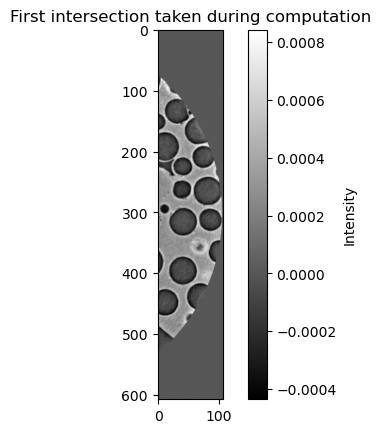

[501 859] [ 868 1042]
Intersecting slice 4 and bounding box coords:
(805, 738) [501 859] [ 868 1042]
Command to check in Fiji: 
makeRectangle(501, 868, 358, 174)
[501 859] [1302 1476]
Intersecting slice 1 and bounding box coords:
(805, 1606) [501 859] [1302 1476]
Command to check in Fiji: 
makeRectangle(501, 1302, 358, 174)
[251 608] [ 868 1041]
Intersecting slice 6 and bounding box coords:
(304, 737) [251 608] [ 868 1041]
Command to check in Fiji: 
makeRectangle(251, 868, 357, 173)


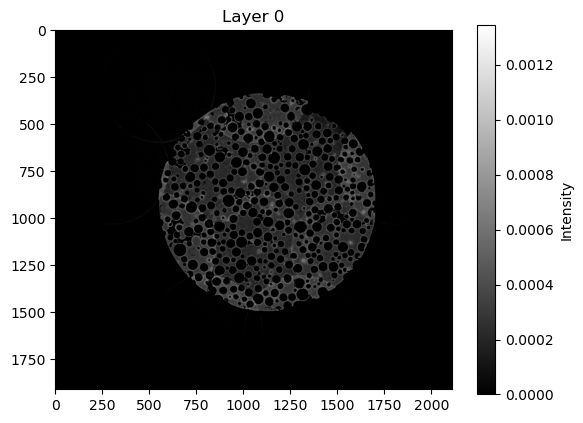

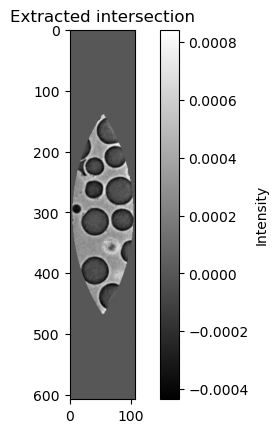

Registration data will be saved at: /data/visitors/danmax/20240533/2024101108/process/Stitcher_v0-2/with_rotation/step01/stitch_layers/Correlation_process
To prepare data took 0.2 seconds
At index 0 of 100
At index 0 of 100
To NCC correlation took 10.0 seconds
Initial correlation x = 2, y = -2, z = 0, NCC = 95.0
To Lucas-Kanade took 10.7 seconds
To prepare data took 0.2 seconds
At index 0 of 100
At index 0 of 100
To NCC correlation took 8.3 seconds
Initial correlation x = -1, y = -3, z = 0, NCC = 89.7
To Lucas-Kanade took 8.9 seconds
To prepare data took 0.2 seconds
At index 0 of 100
At index 0 of 100
To NCC correlation took 8.3 seconds
Initial correlation x = 3, y = 3, z = 0, NCC = 84.6
To Lucas-Kanade took 8.8 seconds
To prepare data took 0.2 seconds
At index 0 of 100
At index 0 of 100
To NCC correlation took 8.5 seconds
Initial correlation x = -4, y = -2, z = 0, NCC = 51.0
To Lucas-Kanade took 8.9 seconds
Layer_0_subvolume_0_intersection_5 --> dx, dy, dz: 2.16, -2.79, -0.05 (NCC = 9

In [ ]:
import sys
import os
# (removed old sys.path manipulation; install the package with `pip install -e .`)import numpy as np
from matplotlib import pyplot as plt
import h5py
import os
import time
import tifffile as tif
from time import time as timing
import sys
from tqdm import tqdm
from stitcher import Stitcher, Utilities
import cupy as cp
import stitcher.danmax as DM  # only on DanMAX beamline
from IPython.display import clear_output
import SimpleITK as sitk

# Get the current proposal
proposal, visit = DM.getCurrentProposal()

# Set the path to the directory containing the scans
path = "/data/visitors/danmax/20240533/2024101108/process/recon_bin2/sample1_Al99p5_2mm/"

steps = [1,2]
start_indexes = [1367,1393,1419,1445,1471,1497,1523,1549,1575,1601,1626,1653,1679,1705,1731,1757,1783,1809,1835,1861,1887,1913,1939,1965,1991,2016,2043,2069,2095,2121,2147,2173,2199,2225]
end_indexes = [1392,1418,1444,1470,1496,1522,1548,1574,1600,1626,1652,1678,1704,1730,1756,1782,1808,1834,1860,1886,1912,1938,1964,1990,2016,2042,2068,2094,2120,2146,2172,2198,2224,2250]

for loop_i, step in enumerate(steps):
    
    start_time = time.time()
    
    # Set the path to the directory to save the raw projections and the stitched ones
    path_save_stitcher = f"/data/visitors/danmax/20240533/2024101108/process/Stitcher_v0-2/with_rotation/step{step:02d}/"
    if not os.path.exists(path_save_stitcher):
        os.makedirs(path_save_stitcher)
    
    # Get all the scans in the specified path
    scans_in_path = [file.split("_dxchange_recon_bin2.h5")[0] for file in os.listdir(path) if file.endswith("_dxchange_recon_bin2.h5")]
    
    scan_no = [int(scan.split('-')[1]) for scan in scans_in_path]
    
    # Get the scan number in the specified path for the specified step
    scan_no_step = [i for i in scan_no if ((i >= start_indexes[loop_i]) and (i <= end_indexes[loop_i]))]
    
    # Get the x, y and z coordinates of the motors
    motor_positions = []
    for i,scan in enumerate(scan_no_step):
        h5file = f"/data/visitors/danmax/20240533/2024101108/raw/sample1_Al99p5_2mm/scan-{scan:04d}.h5"
        with h5py.File(h5file, 'r') as f:
            tom_x=f['/entry/instrument/start_positioners/tom_sam_x'][()]
            tom_y=f['/entry/instrument/start_positioners/tom_y'][()]
            tom_z=f['/entry/instrument/start_positioners/tom_sam_z'][()]
            motor_positions.append([tom_x.copy(), tom_y.copy(), tom_z.copy()])
            
    motor_positions=np.array(motor_positions)
    
    # Stitch initial parameters
    file_path_list = [path + f"scan-{scan:04d}" + "_dxchange_recon_bin2.h5" for scan in scan_no_step]
    physical_coordinates = motor_positions
    mm_per_voxel = 0.0011*2 #1.1 micron
    x_y_z_correspondance=(-1,3,2)

    ####################################################################################################################################################################################################################################################################################################################
    
    if True:
        # Initialize the stitcher
        stitcher = Stitcher(file_path_list,
                                                physical_coordinates,
                                                mm_per_voxel,
                                                x_y_z_correspondance)
        
        # Get layers along the height
        layers = stitcher.get_layers_in_z(tolerance_mm = 4)
        
        # Compute the padding to form the stitched "mosaic"
        stitcher.get_padding()
        
        # Check the padding if needed
        #stitched_max = stitcher.check_padding(layer_index=0, circular_mask=False)
        #tif.imwrite(path_save + "stitched_max_2.tif", stitched_max)
        
        # Get intersections
        stitcher.get_intersections(check=True)
        
        # Check the padding
        layer = 0
        stitched_max = stitcher.check_padding(layer_index=layer, circular_mask=True)
        
        with h5py.File(path_save_stitcher + f"stitched_max_{layer}.h5", "w") as h5f: h5f.create_dataset("image", data = stitched_max)
        
        # Check the intersection and decide on the mask radius to use for the correlation.
        stitcher.check_intersection(layer=0, image=0, intersection=0, mask=True, mask_radius=300)
        
        # Correlate the intersections
        """
        - The erosion is needed to avoid interpolated regions at the border where 0 values are found. Set it to a minimum of (3,3,3) when only shift is used. In case of an affine transform make sure to take it higher and use odd numbers only.
        - Call help(stitcher.compute_shift_in_layers) and help(stitcher.correlate_intersection) for more info about the other parameters
        - If the intersections are too big, the GPU might saturate and fail (especially if it does not share any memory with the RAM). Try reducing the intersection volumes with the crop and slice selection.
        - Also, in case of large displacements or if the features in the image are fine, use apply_mean_filter_zyx to assist the correlation process.
        - An important aspect to keep in mind: The lucas kanade algorithm does not use a normalized version of the images. In these cases consider a local normalization by applying q masked mean filter option on the self.correlate_intersections function in stitcher. 
        """
        
        t_0 = time.time()
        
        stitcher.erosion_mask_LC_xyz = (7,7,7)
        stitcher.add_value_for_mask = 0 # The 0 values are used for the mask. If your images contain a lot of zeros by default this will make the process difficult. Set this parameter to True is so and it adds a value of one when extracting the data. Set it to false afterwards if you do not want it later.
        
        # Clear the gpu memory
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    
        #stitcher.projection_xy_stitching = True
        stitcher.force_rigid_warp = True
        stitcher.projection_xy_stitching=False
        stitcher.compute_shift_in_layers(start_slice=stitcher.img_depth // 2 - 50,
                                         end_slice=stitcher.img_depth // 2 + 50, 
                                         crop_x=(0,0),
                                         crop_y=(0,0),
                                         equal_crop_xy=None,
                                         reduce_slices_LC=0,
                                         mask=True,
                                         mask_radius=300,
                                         verbose=True,
                                         save_reg=True,
                                         save_path=path_save_stitcher + "stitch_layers/",
                                         downscale=4,
                                         downscale_stages=4,
                                         downscale_LC=False,
                                         spline_interp=True,
                                         apply_mean_filter_zyx=(3,3,3),
                                         apply_detrend_filter_yx=(0,0),
                                         apply_affine_warp=True,
                                         keep_rigid_only=False)
        
        # Clear the gpu memory
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
        
        print(f"It took {np.round(time.time() - t_0, 1)} seconds")
        
        # Set the add_one_for_mask to false
        if stitcher.add_value_for_mask: stitcher.add_value_for_mask = False
        
        # Get the stitching order
        stitcher.get_displacement_pyramid(check=False, starting_coord=(600, 600, 0))
        
        # Accumulate different operators based on the stitching order
        stitcher.accumulate_displacement(exclude_NCC=50, weighted_avg=False, verbose=False, affine_operator=True)
        
        # Check the accumulated displacement if needed
        stitcher.check_accumulated_displacement(verbose=False)
        
        # Compose the final displacement and operators
        stitcher.compose_final_displacements(verbose=False)
        
        stitcher.affine_warp=True # When the registration used is affine, setting this setting to False uses only the shift of the center of the images. Make sure to set it to False if the registration considers only the shifts.
        stitcher.prop_x_y = (0,0) # If using a square distance function the prop_x_y sets the propagation direction on the distance field used for blending. If (0,1) only the x axis is used, (1,0) only the y axis is used and if (0,0) the distance function is squared in shape from the image center.
        
        # Clear the gpu memory
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
        
        stitcher.add_value_for_mask = 0
        stitcher.exclude_NCC = 50
    
        stitcher.mask_interpolator = True
        stitcher.affine_interpolator_order = 3
        stitcher.sitk_interpolator = sitk.sitkBSpline # Options for the interpolation in case of a translation only: sitk.Linear, sitk.sitkBSpline5, sitk.sitkBSpline
        
        stitcher.GPU_chunk_size = 1 # Useful only for the affine transformation. It divides the data processing into chungs when applying the affine transform.
        stitch_slice_blend_equalize = stitcher.stitch_volumes_blend_equalize(stitch_layer=None,
                                                                             start_slice=stitcher.img_depth//2 - 1,
                                                                             end_slice=stitcher.img_depth//2 + 1,
                                                                             mask=True,
                                                                             mask_radius=300,
                                                                             alpha=1,
                                                                             use_equalize=True,
                                                                             use_existing_equalize=False,
                                                                             normalize_dist_radially=True,
                                                                             square_dist=False,
                                                                             crop_x=(0, 0),
                                                                             crop_y=(0, 0),
                                                                             exclude_indexes=[],
                                                                             exclude_NCC=True,
                                                                             show_progress_bar=True)
        
        # Clear the gpu memory
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
        
        # Check the stitched image. The h5 file can be opened directly in jupiter.
        if len(stitcher.layers_paths) > 1:
            for i, image in enumerate(stitch_slice_blend_equalize):
                with h5py.File(path_save_stitcher + f"Stitched_slices_short_{i}.h5", "w") as h5f: h5f.create_dataset("image", data = image)
        else:
            with h5py.File(path_save_stitcher + "Stitched_slices_short.h5", "w") as h5f: h5f.create_dataset("image", data = stitch_slice_blend_equalize)

        sys.exit()
        
        # Push the current parameters as the final ones
        stitcher.push_stitch_parameters()
        
        # Stitch the full volume
        stitcher.GPU_chunk_size = 1 # The GPU_chunk_size is required only for affine transform stitcher.affine_warp = True and when an affine registration has been performed
        stitcher.stitch_layers(chunk_size_series = 400, chunk_size_parallel = 50, n_cores = 8, use_existing_equalize=True, path_save=path_save_stitcher, check=False)
        # Clear the gpu memory if using it with the affine transform
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()



    
    
    ################################################################################################################################################## Stitching along the height ##################################################################################################################################################################################
    ################################################################################################################################################## Stitching along the height ##################################################################################################################################################################################
    ################################################################################################################################################## Stitching along the height ##################################################################################################################################################################################
    ################################################################################################################################################## Stitching along the height ##################################################################################################################################################################################
    ################################################################################################################################################## Stitching along the height ##################################################################################################################################################################################
    ################################################################################################################################################## Stitching along the height ##################################################################################################################################################################################
    
    
    
    
    
    
    
    # Get the layers
    file_path_list = [path_save_stitcher + "Stitched_layers/" + file_name for file_name in os.listdir(path_save_stitcher + "Stitched_layers") if (file_name.endswith(".h5")) and (file_name.startswith("Layer_")) and not (file_name.endswith("flipped.h5"))]
    
    """
    Transpose the images
    The transposed images are saved with the extension _flipped.h5. These data are left to the user to manage them after the computation is over.
    """

    ####################################################################################################################################################################################################################################################################################################################
    
    if True:
        batch_size = 100  # adjust based on your RAM / the number of images to be flipped at once
        
        for i, img_file in enumerate(file_path_list):
            with h5py.File(img_file, 'r') as f_in:
        
                dset = f_in['stitched_data']['stitched_image']
                shape = dset.shape  # (Z, Y, X)
                dtype = dset.dtype
        
                out_file = img_file.replace(".h5", "_flipped.h5")
                with h5py.File(out_file, 'w') as f_out:
                    grp = f_out.create_group('entry/instrument/zyla')
                    out_dset = grp.create_dataset(
                        'data',
                        shape=(shape[1], shape[0], shape[2]),  # (Y, Z, X)
                        dtype=dtype,
                        #chunks=(shape[1], 1, shape[2])  # do not optimize for axis 1 writing as the images are then to be read later
                    )
                    
                    for z in tqdm(range(0, shape[0], batch_size), desc=f"Processing HDF5 files on layers {i}"):
                        z_end = min(z + batch_size, shape[0])
                        batch = dset[z:z_end, :, :]  # (B, Y, X)
        
                        # Efficient transpose: (B, Y, X) -> (Y, B, X)
                        transposed_batch = np.einsum('byx->ybx', batch)
                        out_dset[:, z:z_end, :] = transposed_batch
        
    # Get the coordinates and the list of images
    layer_coordinates_xyz = []
    file_path_list_flipped = []
    
    for img_file in file_path_list:
        with h5py.File(img_file, 'r') as f_in:
            coords = np.mean(f_in['stitched_data']['layer_coordinates'][:], axis=0)[[0, 2, 1]]
            layer_coordinates_xyz.append(np.array([coords[0], coords[1], 0])) # The z is not important so we set it to 0 to make sure that only one layer will be considered
            
        file_path_list_flipped.append(path_save_stitcher + "Stitched_layers/" + img_file.split("/")[-1].replace(".h5", "_flipped.h5"))
    
    # Initialize the stitcher
    mm_per_voxel = 1
    physical_coordinates = np.array(layer_coordinates_xyz)
    x_y_z_correspondance=(-1,-2,3)
    
    stitcher_height = Stitcher(file_path_list_flipped,
                                                   physical_coordinates,
                                                   mm_per_voxel,
                                                   x_y_z_correspondance)
    
    # Get layers along the height
    layers = stitcher_height.get_layers_in_z(tolerance_mm = 1)
    
    # Compute the padding to form the stitched "mosaic"
    stitcher_height.get_padding()
    
    # Check the padding if needed
    stitched_max = stitcher_height.check_padding(layer_index=0, circular_mask=False)
    #tif.imwrite(path_save_stitcher + "Stitched_layers/" + "stitched_max_2.tif", stitched_max)
    
    # Get intersections
    stitcher_height.get_intersections(check=False)
    
    # Check the padding
    stitched_max = stitcher_height.check_padding(layer_index=0, circular_mask=False)
    
    # Check the intersection and decide on the mask radius to use for the correlation.
    stitcher_height.check_intersection(layer=0, image=0, intersection=0, mask=True, mask_radius=4000)
    
    # Correlate the intersections
    """
    - The erosion is needed to avoid interpolated regions at the border where 0 values are found. Set it to a minimum of (3,3,3) when only shift is used. In case of an affine transform make sure to take it higher and use odd numbers only.
    - Call help(stitcher.compute_shift_in_layers) and help(stitcher.correlate_intersection) for more info about the other parameters
    - If the intersections are too big, the GPU might saturate and fail (especially if it does not share any memory with the RAM). Try reducing the intersection volumes with the crop and slice selection.
    - Also, in case of large displacements or if the features in the image are fine, use apply_mean_filter_zyx to assist the correlation process.
    - An important aspect to keep in mind: The lucas kanade algorithm does not use a normalized version of the images. In these cases consider a local normalization by applying q masked mean filter option on the self.correlate_intersections function in stitcher. 
    """
    
    t_0 = time.time()
    
    stitcher_height.erosion_mask_LC_xyz = (7,7,7)
    stitcher_height.add_value_for_mask = 0 # The 0 values are used for the mask. If your images contain a lot of zeros by default this will make the process difficult. Set this parameter to True is so and it adds a value of one when extracting the data. Set it to false afterwards if you do not want it later.
    stitcher_height.projection_xy_stitching = False
    stitcher_height.force_rigid_warp = False
    stitcher_height.compute_shift_in_layers(start_slice=stitcher_height.img_depth // 2 - 300,
                                            end_slice=stitcher_height.img_depth // 2 + 300,
                                            crop_x=(750,1500),
                                            crop_y=(0,0),
                                            equal_crop_xy=None,
                                            reduce_slices_LC=0,
                                            mask=True,
                                            mask_radius=2000,
                                            verbose=True,
                                            save_reg=True,
                                            save_path=path_save_stitcher + "Stitched_layers/",
                                            downscale=4,
                                            downscale_stages=2,
                                            downscale_LC=False,
                                            spline_interp=False,
                                            apply_mean_filter_zyx=(3,3,3),
                                            apply_affine_warp=False,
                                            keep_rigid_only=False)
    
    print(f"It took {np.round(time.time() - t_0, 1)} seconds")
    
    # Set the add one for mask to false
    if stitcher_height.add_value_for_mask != 0: stitcher_height.add_value_for_mask = 0
    
    # Get the stitching order
    stitcher_height.get_displacement_pyramid(check=False, starting_coord=(0, 0, 0))
    
    # Accumulate different operators based on the stitching order
    stitcher_height.accumulate_displacement(exclude_NCC=25, weighted_avg=False, verbose=False, affine_operator=False)
    
    # Check the accumulated displacement if needed
    stitcher_height.check_accumulated_displacement(verbose=True)
    
    # Compose the final displacement and operators
    stitcher_height.compose_final_displacements(verbose=True)
    
    stitcher_height.affine_warp=False # When the registration used is affine, setting this setting to False uses only the shift of the center of the images. Make sure to set it to False if the registration considers only the shifts.
    stitcher_height.prop_x_y = (0,1) # If using a square distance function the prop_x_y sets the propagation direction on the distance field used for blending. If (0,1) only the x axis is used, (1,0) only the y axis is used and if (0,0) the distance function is squared in shape from the image center.
    
    stitcher_height.add_value_for_mask = 0

    stitcher_height.exclude_NCC = -200

    stitcher_height.mask_interpolator = True
    stitcher_height.affine_interpolator_order = 3

    stitcher_height.GPU_chunk_size = 5
    stitch_slice_blend_equalize = stitcher_height.stitch_volumes_blend_equalize(stitch_layer=None,
                                                                                start_slice=stitcher_height.img_depth//2 - 100,
                                                                                end_slice=stitcher_height.img_depth//2 + 100,
                                                                                mask=True,
                                                                                mask_radius=4000,
                                                                                alpha=1, 
                                                                                use_equalize=True, 
                                                                                use_existing_equalize=False,
                                                                                normalize_dist_radially=False,
                                                                                square_dist=True, 
                                                                                crop_x=(0, 0),
                                                                                crop_y=(0, 0),
                                                                                exclude_indexes=[],
                                                                                exclude_NCC=True,
                                                                                show_progress_bar=True)
    
    # Clear the gpu memory
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()
    
    # Check the stitched image. The h5 file can be opened directly in jupiter.
    with h5py.File(path_save_stitcher + "Stitched_layers/" + "Stitched_slices.h5", "w") as h5f: h5f.create_dataset("image", data = stitch_slice_blend_equalize)
    
    # Push the current parameters as the final ones
    stitcher_height.push_stitch_parameters()
    
    # Release some memory
    del stitch_slice_blend_equalize
    # Stitch the full volume
    stitcher_height.GPU_chunk_size = 5 # The GPU_chunk_size is required only for affine transform stitcher.affine_warp = True and when an affine registration has been performed
    stitcher_height.stitch_layers(chunk_size_series = 160, chunk_size_parallel = 20, n_cores = 8, use_existing_equalize=True, path_save=path_save_stitcher + "Stitched_layers/Full_stitch/", check=False)
    # Clear the gpu memory
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()

    clear_output(wait=False)

    print(f"It took {np.round((time.time() - start_time) / 60)} minutes")

Stitching Layer 0: 12it [00:12,  1.02s/it]                                                          
Stitching Layer 1: 14it [00:12,  1.09it/s]                                                          


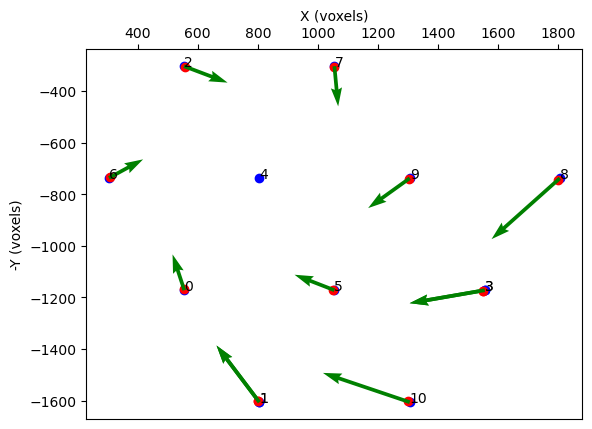

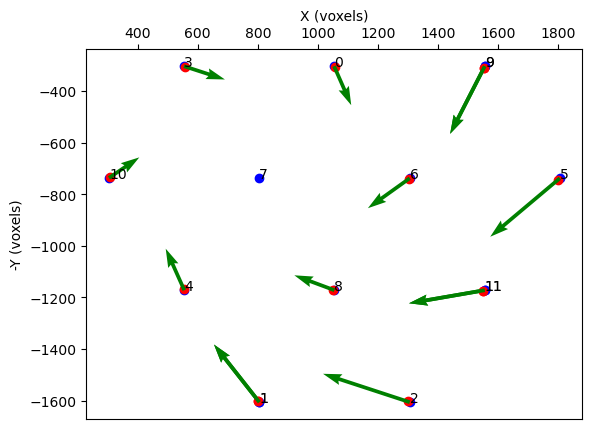

In [2]:
if stitcher.add_value_for_mask: stitcher.add_value_for_mask = False

# Get the stitching order
stitcher.get_displacement_pyramid(check=False, starting_coord=(600, 600, 0))

# Accumulate different operators based on the stitching order
stitcher.accumulate_displacement(exclude_NCC=85, weighted_avg=False, verbose=False, affine_operator=False)

# Check the accumulated displacement if needed
stitcher.check_accumulated_displacement(verbose=False)

# Compose the final displacement and operators
stitcher.compose_final_displacements(verbose=False)

stitcher.affine_warp=False # When the registration used is affine, setting this setting to False uses only the shift of the center of the images. Make sure to set it to False if the registration considers only the shifts.
stitcher.prop_x_y = (0,0) # If using a square distance function the prop_x_y sets the propagation direction on the distance field used for blending. If (0,1) only the x axis is used, (1,0) only the y axis is used and if (0,0) the distance function is squared in shape from the image center.

# Clear the gpu memory
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

stitcher.add_value_for_mask = 0
stitcher.exclude_NCC = 85

stitcher.mask_interpolator = True
stitcher.affine_interpolator_order = 1
stitcher.sitk_interpolator = sitk.sitkBSpline # Options for the interpolation in case of a translation only: sitk.Linear, sitk.sitkBSpline5, sitk.sitkBSpline

stitcher.GPU_chunk_size = 1 # Useful only for the affine transformation. It divides the data processing into chungs when applying the affine transform.
stitch_slice_blend_equalize = stitcher.stitch_volumes_blend_equalize(stitch_layer=None,
                                                                     start_slice=stitcher.img_depth//2 - 1,
                                                                     end_slice=stitcher.img_depth//2 + 1,
                                                                     mask=True,
                                                                     mask_radius=300,
                                                                     alpha=1,
                                                                     use_equalize=True,
                                                                     use_existing_equalize=False,
                                                                     normalize_dist_radially=True,
                                                                     square_dist=False,
                                                                     crop_x=(0, 0),
                                                                     crop_y=(0, 0),
                                                                     exclude_indexes=[],
                                                                     exclude_NCC=True,
                                                                     show_progress_bar=True)

# Clear the gpu memory
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

# Check the stitched image. The h5 file can be opened directly in jupiter.
if len(stitcher.layers_paths) > 1:
    for i, image in enumerate(stitch_slice_blend_equalize):
        with h5py.File(path_save_stitcher + f"Stitched_slices_short_{i}.h5", "w") as h5f: h5f.create_dataset("image", data = image)
else:
    with h5py.File(path_save_stitcher + "Stitched_slices_short.h5", "w") as h5f: h5f.create_dataset("image", data = stitch_slice_blend_equalize)


In [2]:
import sys
import os
# (removed old sys.path manipulation; install the package with `pip install -e .`)import numpy as np
from matplotlib import pyplot as plt
import h5py
import os
import time
import tifffile as tif
from time import time as timing
import sys
from tqdm import tqdm
import cupy as cp
# Optional: import stitcher.danmax as DM  # only on DanMAX beamline
from IPython.display import clear_output

def convert(img, maxValue=255, minImg=-4.17E-4, maxImg=5.99E-4, data_type=np.uint8):
        """
        Converts an image (img) of a given type to another specified by the data_type input.
        The maxValue is the maxValue to be signed to the image after conversion. This is used because later one or more values could be added for masking purposes.
        minImg and maxImg are the minimum and maximum values that will be converted. Every value falling lower or higher are converted to the minImg and maxImg.
        """
        if type(minImg) == type(None): minImg = img.min()
        if type(maxImg) == type(None): maxImg = img.max()
        if type(maxValue) == type(None): maxValue = 65535
        
        # Step 1: Set any values lower than minImg to 0 and higher than maxImg to maxValue
        img = np.clip(img, a_min = minImg, a_max = maxImg)
        
        # Step 2: Normalize values within [minImg, maxImg] to the range [0, 1]
        img = (img - minImg) / (maxImg - minImg)
        
        # Step 3: Scale normalized values to [0, maxValue]
        img = (img * maxValue).astype(data_type)
        
        return img

steps = [1,2]
steps_save = [0,1]
for loop_i, step in enumerate(steps):
    # Get the path
    path_save_stitcher = f"/data/visitors/danmax/20240533/2024101108/process/Stitcher_v0-2/with_rotation/step{step:02d}/"
    stitched_img_path = path_save_stitcher + f"Stitched_layers/Full_stitch/Stitched_layers/Layer_0.h5"
    # data pointer
    stitched_img = h5py.File(stitched_img_path, "r")['stitched_data/stitched_image/'][:, :, :]
    # convert to 8-bit
    stitched_img = convert(stitched_img)
    # save path
    path_save_img = os.path.join("/data/visitors/danmax/20240533/2024101108/process/Stitcher_v0-2/with_rotation", f"step_{step:02d}_{steps_save[loop_i]}.tif")
    # save as tif
    tif.imwrite(path_save_img, stitched_img)